In [12]:
data_path = "heart"

In [ ]:
!pip install scikit-image
!pip install wandb
!pip install monai

In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt
import glob
import monai
from PIL import Image
import torch
import re
import torchvision.transforms as transforms

def build_dict_heart(data_path, mode='train'):
    """
    This function returns a list of dictionaries, each dictionary containing the keys 'img' and 'mask' 
    that returns the path to the corresponding image.
    
    Args:
        data_path (str): path to the root folder of the data set.
        mode (str): subset used. Must correspond to 'train', 'val' or 'test'.
        
    Returns:
        (List[Dict[str, str]]) list of the dictionaries containing the paths of X-ray images and masks.
    """
    # test if mode is correct
    if mode not in ["train", "val", "test"]:
        raise ValueError(f"Please choose a mode in ['train', 'val', 'test']. Current mode is {mode}.")
    
    # define empty dictionary
    dicts = []
    # list all .png files in directory, including the path
    paths_xray = glob.glob(os.path.join(data_path, mode, 'img', '*.nii'))
    # make a corresponding list for all the mask files
    for xray_path in paths_xray:
        if mode == 'test':
            suffix = 'val'
        else:
            suffix = mode
        # find the binary mask that belongs to the original image, based on indexing in the filenam
        numbers = re.findall(r'\d+', xray_path)
        image_index = os.path.join(data_path, mode, 'img', f'CMD{numbers[0]}Gate{numbers[1]}.nii')
        # define path to mask file based on this index and add to list of mask paths
        mask_path = os.path.join(data_path, mode, 'mask', f'DCM{numbers[0]}-OH-AL_V2_{numbers[1]}.nii')
        if os.path.exists(mask_path):
            dicts.append({'img': xray_path, 'mask': mask_path})
    return dicts

class MedMNISTData(monai.data.Dataset):
    
    def __init__(self, datafile, transform=None):
        self.data = datafile
        self.transform = transform
        
        
    def __getitem__(self, index):
        # Make getitem return a dictionary with keys ['img', 'mask'] for the image and mask respectively
        image = self.data[index]['img']
        mask = self.data[index]['mask']
        
        image = loader(image)[0]
        mask = loader(mask)[0]
        if self.transform:
            image = self.transform(image)
        return {'img': image, 'mask': mask}
    
    def __len__(self):
        return len(self.data)
    
def dataviewer(image):
    loader = LoadImage(image_only=False)
    image, meta = loader(image)
    return image.shape, meta

def visualize_rib_sample(sample, title=None):
    # Visualize the x-ray and overlay the mask, using the dictionary as input
    image = np.squeeze(sample['img'])
    mask = np.squeeze(sample['mask'])
    
    plt.figure(figsize=[10,7])
    plt.imshow(image, 'gray')
    
    mask1 = np.ma.masked_where(mask != 1, mask)
    plt.imshow(mask1, 'Greens', alpha = 0.5, clim=[0,1], interpolation='nearest')

    mask2 = np.ma.masked_where(mask != 2, mask)
    plt.imshow(mask2, 'Reds', alpha = 0.5, clim=[0,1], interpolation='nearest')
    
    mask3 = np.ma.masked_where(mask != 3, mask)
    plt.imshow(mask3, 'Blues', alpha = 0.5, clim=[0,1], interpolation='nearest')
    if title is not None:
        plt.title(title)
    plt.show()

In [25]:
train_dict_list = build_dict_heart(data_path, mode='train')
shape, meta = dataviewer(train_dict_list[0]['img'])

In [26]:
data_transform = transforms.Compose([
    transforms.Normalize(mean=[.5], std=[.5])
])

# construct CacheDataset from list of paths + transform
train_dataset = MedMNISTData(train_dict_list, transform=data_transform)

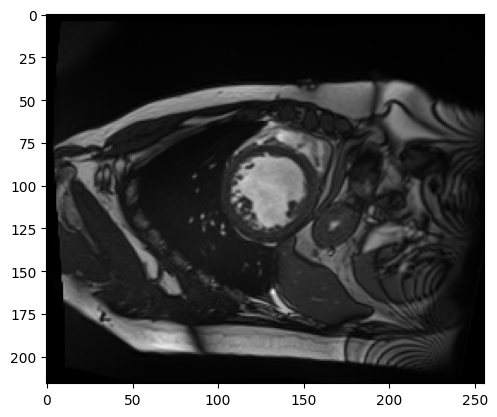

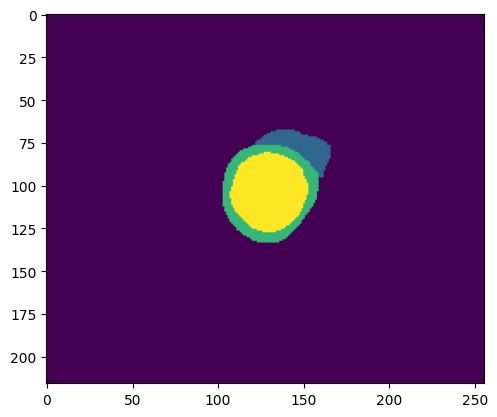

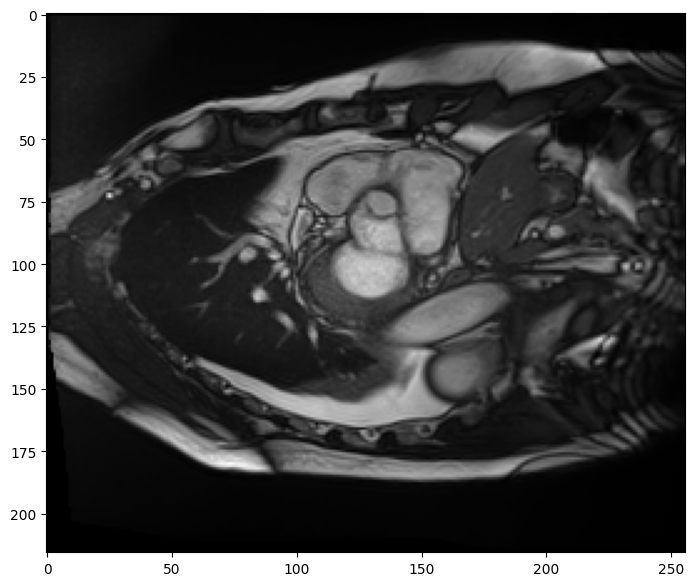

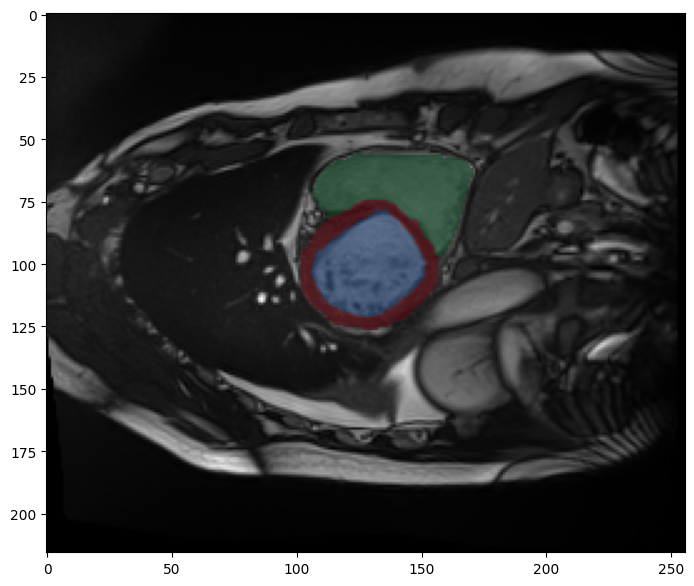

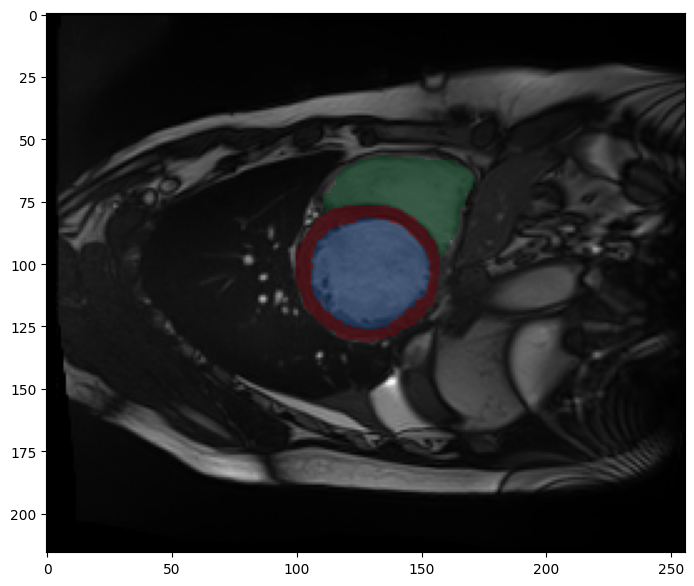

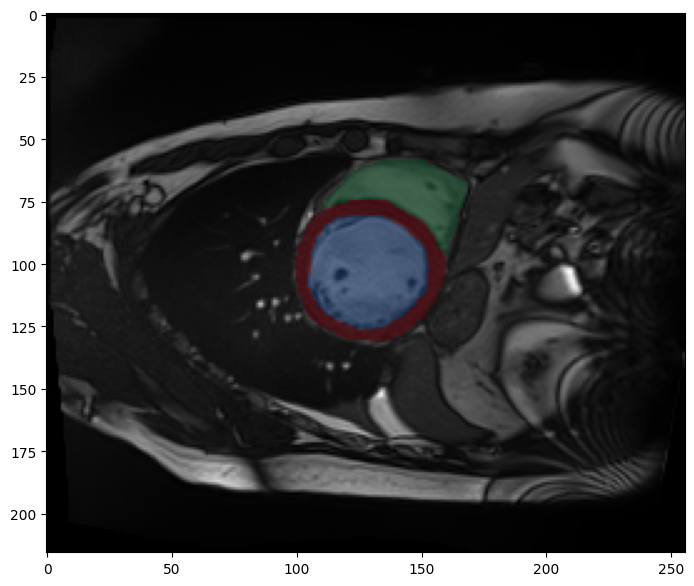

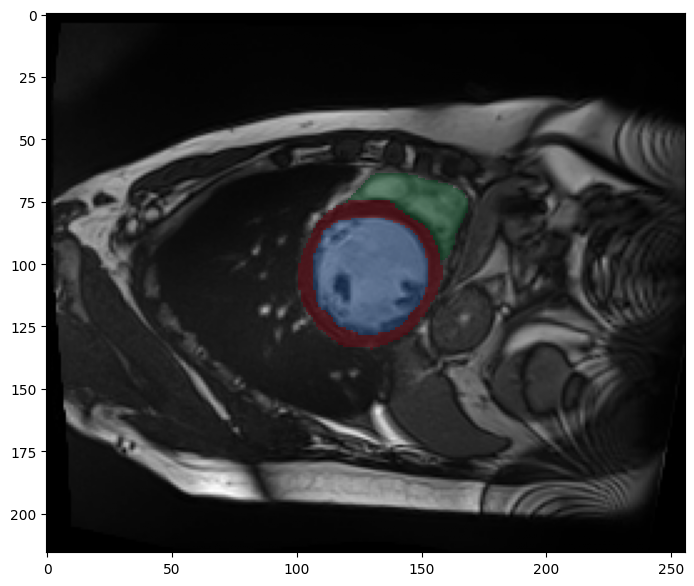

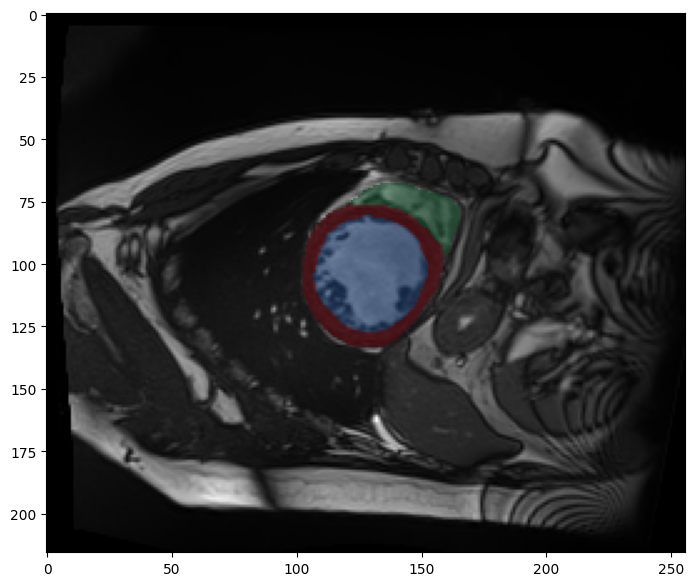

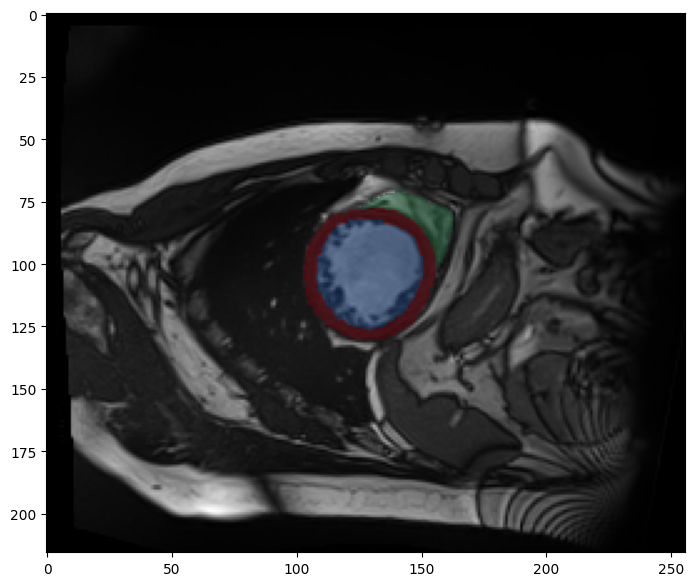

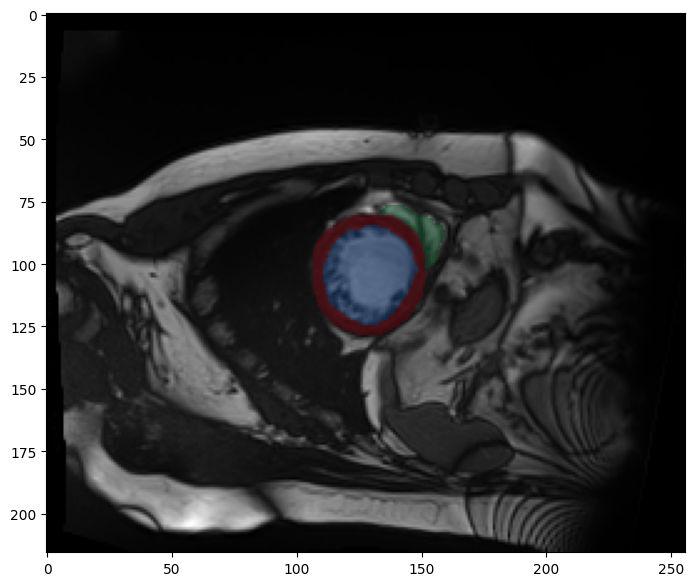

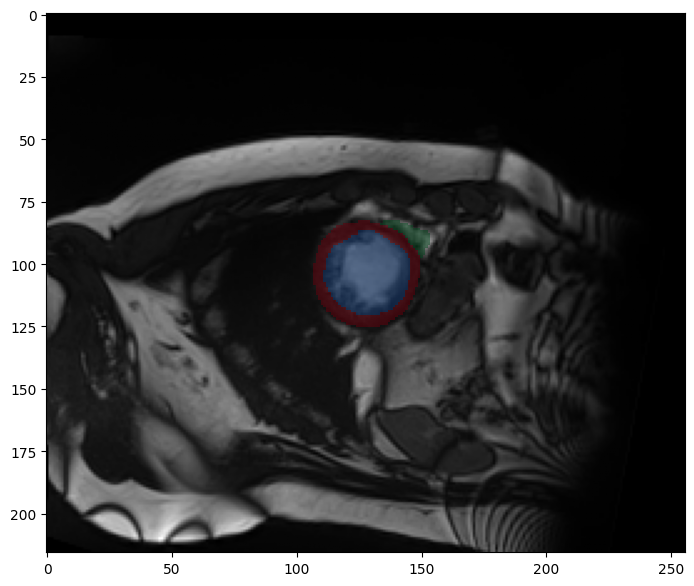

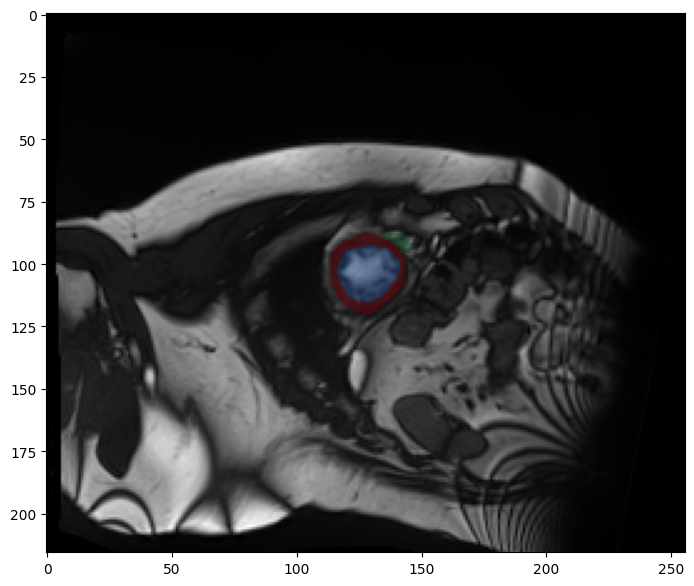

In [29]:
plt.figure()
plt.imshow(train_dataset[0]['img'][:,:,5], cmap='gray')
plt.show()

plt.imshow(train_dataset[0]['mask'][:,:,5])
plt.show()

for i in range(shape[2]):
    single_data = train_dataset[0]
    slice = i
    sample_slice = {
    'img': single_data['img'][:, :, slice],
    'mask': single_data['mask'][:, :, slice]}
    visualize_rib_sample(sample_slice)